# 章节: 时间序列分析：概念与应用

## 主题: 使用ARMA监控受控变量

In [2]:
# 导入包
import matplotlib.pyplot as plt, numpy as np
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import arma_order_select_ic
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({'font.size': 14})

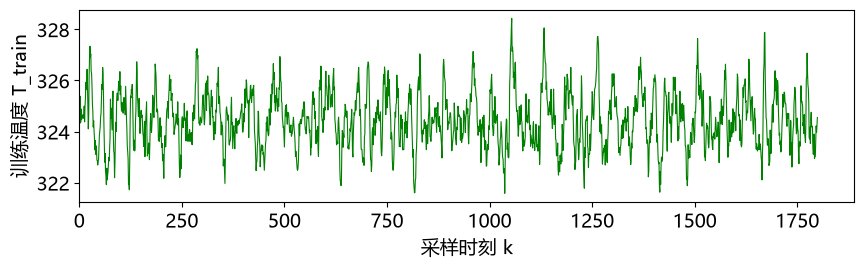

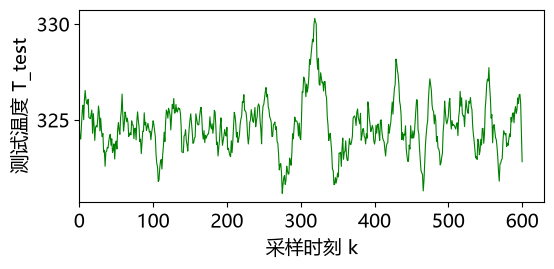

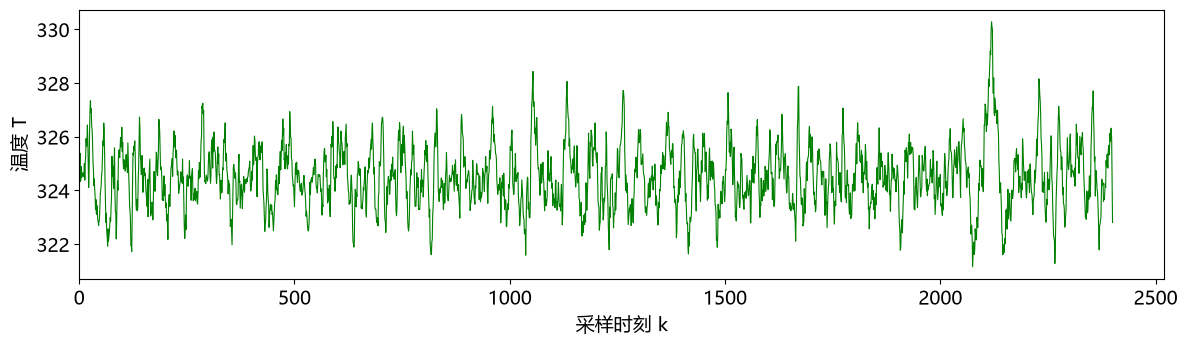

In [3]:
# 读取数据并划分为训练集与测试集
T = np.loadtxt('CSTR_controlledTemperature.csv', delimiter=',')
T_train = T[:1800]; T_test = T[1800:]

# 绘图
plt.figure(figsize=(10,2.5))
plt.plot(T_train, 'g', linewidth=0.8)
plt.ylabel('训练温度 T_train'), plt.xlabel('采样时刻 k'), plt.xlim(0)

plt.figure(figsize=(6,2.5))
plt.plot(T_test, 'g', linewidth=0.8)
plt.ylabel('测试温度 T_test'), plt.xlabel('采样时刻 k'), plt.xlim(0)

plt.figure(figsize=(14,3.5))
plt.plot(T, 'g', linewidth=0.8)
plt.ylabel('温度 T'), plt.xlabel('采样时刻 k'), plt.xlim(0)
plt.show()

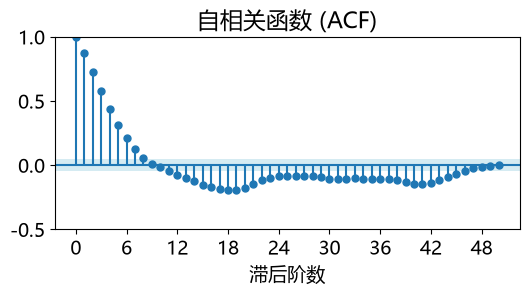

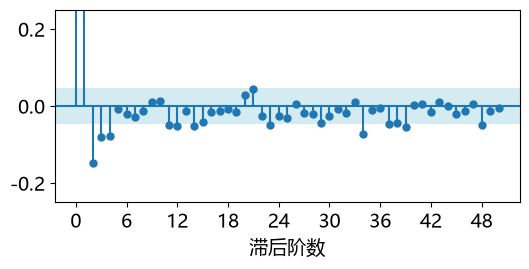

In [4]:
# T_train的自相关函数(ACF)
conf_int = 2/np.sqrt(len(T_train))

fig, ax = plt.subplots(1,1,figsize=(6,2.5))
plot_acf(T_train, lags= 50, alpha=None, title='', ax=ax)
plt.gca().axhspan(-conf_int, conf_int, facecolor='lightblue', alpha=0.5) # shaded confidence interval
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) # integer xtick labels
plt.xlabel('滞后阶数'), plt.ylim((-0.5, 1)), plt.title('自相关函数 (ACF)')
plt.show()

fig, ax = plt.subplots(1,1,figsize=(6,2.5))
plot_pacf(T_train, lags= 50, alpha=None, title='', ax=ax)
plt.gca().axhspan(-conf_int, conf_int, facecolor='lightblue', alpha=0.5) # shaded confidence interval
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) # integer xtick labels
plt.xlabel('滞后阶数'), plt.ylim((-0.25, 0.25))
plt.show()

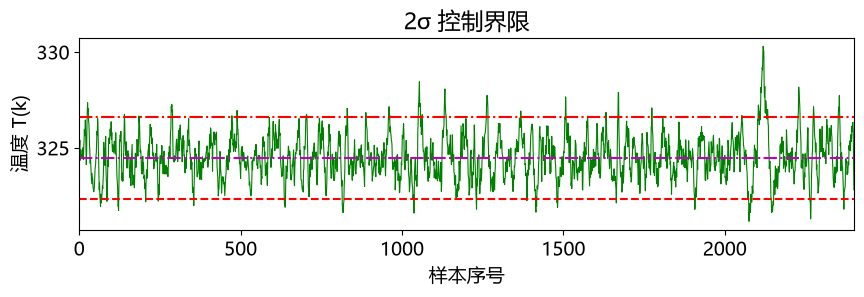

In [5]:
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                         残差均值 ± 2倍标准差边界
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
mu_T_train = np.mean(T_train)
sigma_T_train = np.std(T_train)

# 绘图
plt.figure(figsize=(10,2.5))
plt.plot(T, 'g', linewidth=0.8)
plt.hlines(mu_T_train, 0, len(T), colors='m', linestyles='dashdot', label='均值') 
plt.hlines(mu_T_train+2*sigma_T_train, 0, len(T), colors='r', linestyles='dashdot', label='上界') 
plt.hlines(mu_T_train-2*sigma_T_train, 0, len(T), colors='r', linestyles='dashed', label='下界') 

plt.xlabel('样本序号'), plt.ylabel('温度 T(k)')
plt.xlim((0,len(T)))
plt.title('2σ 控制界限')
plt.show()

In [6]:
#%% %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                         拟合ARMA模型
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [6]:
# 确定最优AR与MA阶数
T_train_centered = T_train - np.mean(T_train); T_test_centered = T_test - np.mean(T_train)
res = arma_order_select_ic(T_train_centered, max_ar=5, max_ma=5, ic=["aic"])
p, r = res.aic_min_order
print('(p, r) = ', res.aic_min_order)

D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\MyWork\ML

(p, r) =  (np.int64(2), np.int64(4))


D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
#%% Fit an ARMA(p,r) model
model = ARIMA(T_train_centered, order=(p, 0, r)) # order = (p,d,r)
results = model.fit()

# 打印拟合摘要信息
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1800
Model:                 ARIMA(2, 0, 4)   Log Likelihood               -1334.150
Date:                Mon, 29 Jun 2026   AIC                           2684.300
Time:                        15:29:40   BIC                           2728.265
Sample:                             0   HQIC                          2700.529
                               - 1800                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0028      0.002      1.242      0.214      -0.002       0.007
ar.L1          1.7979      0.021     86.408      0.000       1.757       1.839
ar.L2         -0.8111      0.021    -39.237      0.0

D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
#%% %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                         残差分析
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

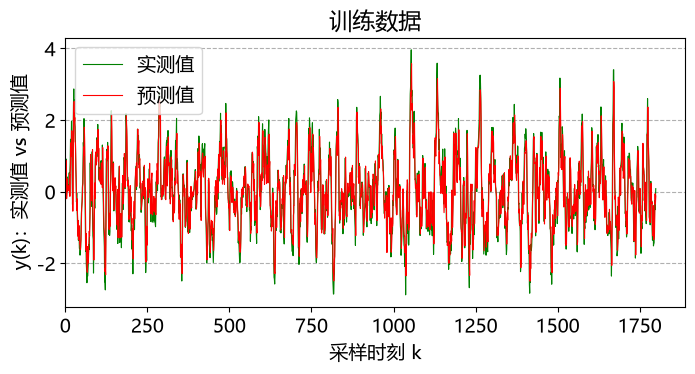

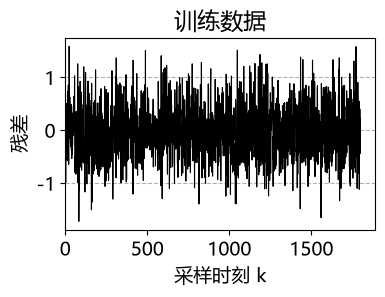

In [8]:
# 获取训练集上的模型预测与残差
T_train_centered_pred = results.fittedvalues # same as results.predict()
residuals_train = T_train_centered - T_train_centered_pred # same as results.resid

plt.figure(figsize=(8,3.5)), plt.title('训练数据'), plt.plot(T_train_centered, 'g', linewidth=0.8, label='实测值')
plt.plot(T_train_centered_pred, 'r', linewidth=0.8, label='预测值')
plt.ylabel('y(k)：实测值 vs 预测值'), plt.xlabel('采样时刻 k'), plt.legend(), plt.xlim(0)
plt.grid(which='both', axis='y', linestyle='--')

plt.figure(figsize=(4,2.5)), plt.plot(residuals_train, 'black', linewidth=0.8)
plt.title('训练数据'), plt.ylabel('残差'), plt.xlabel('采样时刻 k'), plt.xlim(0)
plt.grid(which='both', axis='y', linestyle='--')
plt.show()

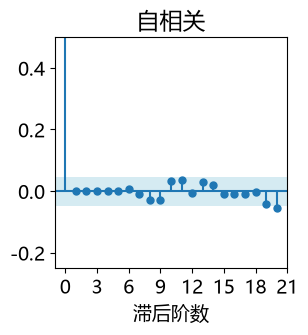

In [9]:
# 训练集残差的自相关函数(ACF)
fig, ax = plt.subplots(1,1,figsize=(3,3))
plot_acf(residuals_train, lags= 20, alpha=None, title='', ax=ax)
plt.gca().axhspan(-conf_int, conf_int, facecolor='lightblue', alpha=0.5) # shaded confidence interval
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) # integer xtick labels
plt.xlabel('滞后阶数'), plt.ylim((-0.25, 0.5)), plt.title('自相关')
plt.show()

In [11]:
#%% %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                         在测试数据上预测
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

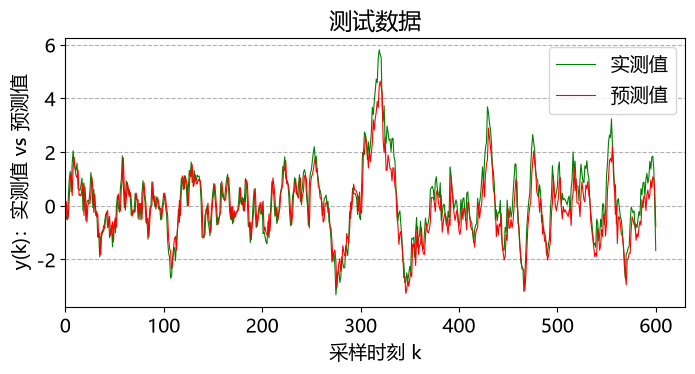

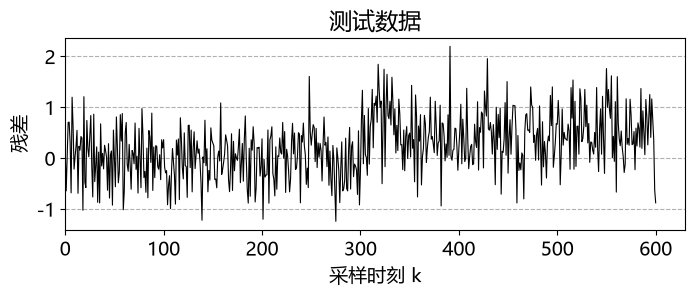

In [10]:
results_test = results.apply(T_test_centered)
T_test_centered_pred = results_test.fittedvalues # same as results_test.predict()
residuals_test = T_test_centered - T_test_centered_pred

plt.figure(figsize=(8,3.5)), plt.title('测试数据'), plt.plot(T_test_centered, 'g', linewidth=0.8, label='实测值')
plt.plot(T_test_centered_pred, 'r', linewidth=0.8, label='预测值')
plt.ylabel('y(k)：实测值 vs 预测值'), plt.xlabel('采样时刻 k'), plt.legend(), plt.xlim(0)
plt.grid(which='both', axis='y', linestyle='--')

plt.figure(figsize=(8,2.5)), plt.plot(residuals_test, 'black', linewidth=0.8)
plt.title('测试数据'), plt.ylabel('残差'), plt.xlabel('采样时刻 k'), plt.xlim(0)
plt.grid(which='both', axis='y', linestyle='--')
plt.show()

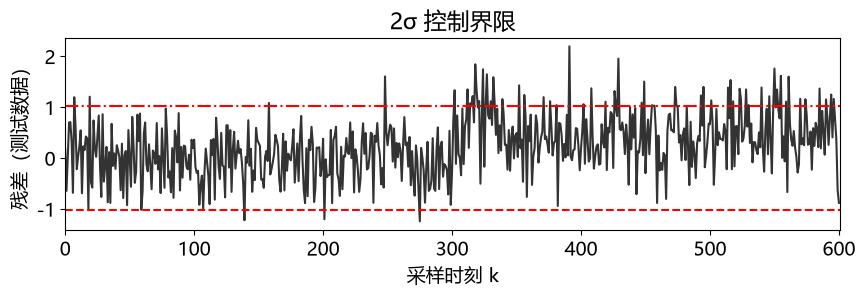

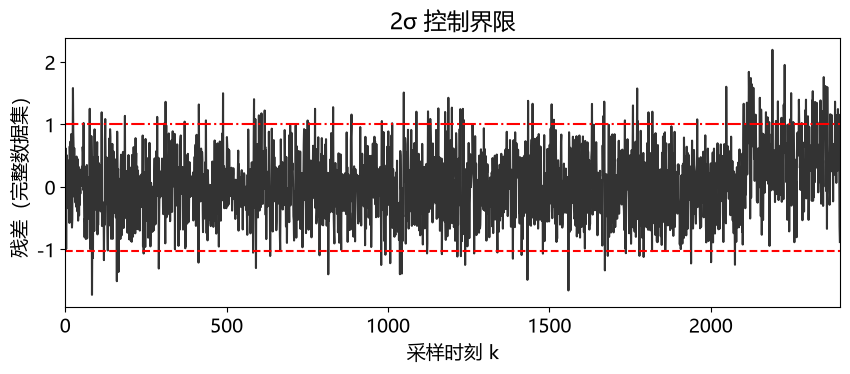

In [11]:
#%% %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                         残差均值 ± 标准差
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
mu_residuals_train = np.mean(residuals_train)
sigma_residuals_train = np.std(residuals_train)

# 绘图
plt.figure(figsize=(10,2.5))
plt.plot(residuals_test, 'black', alpha=0.8, markeredgecolor='k', markeredgewidth=0.1, ms=3)
plt.hlines(mu_residuals_train+2*sigma_residuals_train, 0, len(residuals_test), colors='r', linestyles='dashdot', label='上界') 
plt.hlines(mu_residuals_train-2*sigma_residuals_train, 0, len(residuals_test), colors='r', linestyles='dashed', label='下界') 
plt.xlabel('采样时刻 k'), plt.ylabel('残差（测试数据）')
plt.xlim((0, len(residuals_test)))
plt.title('2σ 控制界限')

# 绘图
residuals = np.hstack((residuals_train, residuals_test))
plt.figure(figsize=(10,3.5))
plt.plot(residuals, 'black', alpha=0.8, markeredgecolor='k', markeredgewidth=0.1, ms=3)
plt.hlines(mu_residuals_train+2*sigma_residuals_train, 0, len(residuals), colors='r', linestyles='dashdot', label='上界') 
plt.hlines(mu_residuals_train-2*sigma_residuals_train, 0,  len(residuals), colors='r', linestyles='dashed', label='下界') 
plt.xlabel('采样时刻 k'), plt.ylabel('残差（完整数据集）')
plt.xlim((0, len(residuals)))
plt.title('2σ 控制界限')
plt.show()